{'poem': '《咏莲》\n碧水清波映日红， \n幽香远溢韵无穷。 \n中通外直尘埃远， \n君子风姿自不同。\n\n注：我的创作思路是捕捉莲花“出淤泥而不染”的高洁品格。首句“碧水清波映日红”以明丽画面展现莲花亭亭之姿，次句“幽香远溢韵无穷”化用周敦颐“香远益清”之典。后两句“中通外直尘埃远”呼应《爱莲说》中通透正直的君子意象，尾句“君子风姿自不同”更为整体赋予人格化的高尚境界。', 'ci_poem': '为您生成两首关于“莲花”的中文词，分别采用《蝶恋花》和《鹧鸪天》的词牌，风格各有侧重。\n\n### 第一首：《蝶恋花·咏莲》\n\n碧水荷塘风袅袅，翠盖摇珠，惊起双栖鸟。\n不共牡丹争媚巧，淤泥未染冰心皎。\n\n玉立亭亭香自杳，月下禅心，静对烟波渺。\n一点灵犀尘外扰，人间何必寻蓬岛。\n\n> **注**：此词以清雅之笔写莲之高洁，上片写景，下片抒怀。“不共牡丹争媚巧”与“淤泥未染”对照，突出莲花不媚俗、出淤泥而不染的品格，末句以“寻蓬岛”收束，点出清净在心、无需外求的禅意。\n\n### 第二首：《鹧鸪天·白莲》\n\n素影亭亭水中央，冰肌玉骨自生凉。\n风来绿浦千层碧，月照清波一脉香。\n\n离色相，破迷茫，不枝不蔓立苍茫。\n此身合在瑶池畔，偶向人间醉一场。\n\n> **注**：此词专咏白莲，以“素影”、“冰肌”写其色泽与气质。“离色相”化用佛家语，呼应莲之“不染”，“不枝不蔓”则取自《爱莲说》。末二句将白莲拟为谪仙，由瑶池偶落到人间，风致绰约，不沾尘俗。', 'joke': '关于“莲花”的笑话，可以考虑以下几个方向。莲花在中文文化里常象征高洁、出淤泥而不染，所以笑话可以围绕这种“神圣感”与现实的反差，或者利用谐音（莲=连）来展开。\n\n这里有几个不同风格的笑话供你选择：\n\n**1. 莲花与泥巴（职场讽刺风）**\n有一天，莲花对身旁的淤泥说：“我出淤泥而不染，大家都夸我高洁。”\n淤泥叹了口气，慢悠悠地说：“姐，你得搞清楚，你那‘不染’是因为你是一朵花。我要是蹭到你身上，那叫‘玷污’；你哪天要是烂在泥里了，那叫‘化作春泥更护花’。说来说去，全让你把理占了，我们这些底层的泥巴，永远只能是背景板。”\n莲花愣了一下，说：“那……我帮你洗洗？”\n淤泥更生气了：“我本来就在水里，还用你洗？”\n\n**2. 谐音梗（冷笑话）**\n问：莲

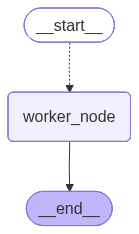

In [2]:
from typing import TypedDict,Literal,Sequence
from wsgiref.util import request_uri

from IPython.core.debugger import prompt
from langchain_deepseek import ChatDeepSeek
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from langchain.messages import HumanMessage
from dotenv import load_dotenv

load_dotenv(override=True)

CONTENT_TYPES = ["poem","joke","ci_poem"]

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking": {
            "type": "disabled"
        }
    }
)

#1. 定义状态
#1.1 全局状态
class OverAllState(TypedDict):
    topic: str
    poem: str
    ci_poem:str
    joke: str

#1.2 私有状态
class workerState(TypedDict):
    content_type: Literal["poem","joke","ci_poem"]
    prompt: str

#1.3 输入状态
class inputState(TypedDict):
    topic: str

#1.4 输出状态
class outputState(TypedDict):
    poem: str
    ci_poem:str
    joke: str

# 2. 定义节点
def worker_node(state:workerState) -> outputState:
    content_type = state["content_type"]
    prompt = state["prompt"]
    content = model.invoke([HumanMessage(prompt)]).content
    return {
        content_type: content
    }

#3. 定义动态分支的路由
def router(state:inputState) -> Sequence[Send]:
    router_prompt = "请生成关于{} 的 {}"
    english2Chinese = {
        "poem": "七言绝句",
        "joke": "笑话",
        "ci_poem": "中文词"
    }
    topic = state["topic"]
    return [
        Send(
            "worker_node",
            {
                "content_type": content_type,
                "prompt": router_prompt.format(topic, english2Chinese[content_type])
            }
        )
        for content_type in CONTENT_TYPES
    ]

#4. 构建图
builder = StateGraph(state_schema=OverAllState,input_schema=inputState,output_schema=outputState)

builder.add_node("worker_node", worker_node)
builder.add_conditional_edges(
    START,
    router,
    path_map=["worker_node"],
    )

builder.add_edge("worker_node",END)

graph = builder.compile()
res = graph.invoke({"topic": "莲花"})
print(res)

from IPython.display import display
display(graph)


